In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


import numpy as np
import seaborn as sns

# Preprocessing

In [3]:
df = pd.read_csv("../Datasets/Warehouse_and_Retail_Sales.csv")
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [7]:
df.shape

(307645, 9)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


In [10]:
df.isna().sum()

YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

In [ ]:
# Change number into float type
num_cols = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
df[num_cols] = df[num_cols].fillna(0)


In [13]:
df[num_cols].describe()

,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307645.000000
mean,7.024003,6.936465,25.294597
std,30.986095,30.237195,249.916798
min,-6.490000,-38.490000,-7800.000000
25%,0.000000,0.000000,0.000000
50%,0.320000,0.000000,1.000000
75%,3.260000,3.000000,5.000000
max,2739.000000,1990.830000,18317.000000


In [20]:
# Total Sales Column
df['TOTAL_SALES'] = (
    df['RETAIL SALES'] +
    df['RETAIL TRANSFERS'] +
    df['WAREHOUSE SALES']
)

df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES', 'TOTAL_SALES']].head()


,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,TOTAL_SALES
0,0.00,0.0,2.0,2.00
1,0.00,1.0,4.0,5.00
2,0.00,0.0,1.0,1.00
3,0.00,0.0,1.0,1.00
4,0.82,0.0,0.0,0.82


In [17]:
df[['YEAR', 'MONTH']].head()

,YEAR,MONTH
0,2020,1
1,2020,1
2,2020,1
3,2020,1
4,2020,1


In [19]:
df['DATE'] = pd.to_datetime(
    df['YEAR'].astype(str) + '-' +
    df['MONTH'].astype(str) + '-01'
)

df[['YEAR', 'MONTH', 'DATE']].head()


,YEAR,MONTH,DATE
0,2020,1,2020-01-01
1,2020,1,2020-01-01
2,2020,1,2020-01-01
3,2020,1,2020-01-01
4,2020,1,2020-01-01


In [22]:
df = df.sort_values(['ITEM CODE', 'DATE'])

In [23]:
df['ITEM CODE'].nunique()

34056

In [24]:
df['ITEM CODE'].value_counts().head()


ITEM CODE
99684    24
99668    24
WC       24
99665    24
7870     24
Name: count, dtype: int64

In [26]:
monthly = df.groupby(
    ['ITEM CODE', 'ITEM DESCRIPTION', 'DATE'],
    as_index=False
)['TOTAL_SALES'].sum()

monthly.head()


,ITEM CODE,ITEM DESCRIPTION,DATE,TOTAL_SALES
0,100002,PATRON TEQUILA SILVER LTD - 1L,2017-07-01,0.17
1,100007,LA CETTO CAB SAUV - 750ML,2019-04-01,1.00
2,100007,LA CETTO CAB SAUV - 750ML,2019-05-01,1.00
3,100007,LA CETTO CAB SAUV - 750ML,2019-10-01,1.00
4,100007,LA CETTO CAB SAUV - 750ML,2019-11-01,1.00


In [27]:
def expand_monthly(ts):
    idx = pd.date_range(ts['DATE'].min(), ts['DATE'].max(), freq='MS')
    ts = ts.set_index('DATE').reindex(idx)
    ts.index.name = 'DATE'
    return ts['TOTAL_SALES'].fillna(0)

panel_list = []

for item, group in monthly.groupby('ITEM CODE'):
    ts = expand_monthly(group[['DATE', 'TOTAL_SALES']])
    df_item = ts.reset_index()
    df_item['ITEM CODE'] = item
    panel_list.append(df_item)

panel = pd.concat(panel_list, ignore_index=True)


In [28]:
panel.head(20)


,DATE,TOTAL_SALES,ITEM CODE
0,2017-07-01,0.17,100002
1,2019-04-01,1.00,100007
2,2019-05-01,1.00,100007
3,2019-06-01,0.00,100007
4,2019-07-01,0.00,100007
5,2019-08-01,0.00,100007
6,2019-09-01,0.00,100007
7,2019-10-01,1.00,100007
8,2019-11-01,1.00,100007
9,2017-06-01,0.00,100008


In [29]:
panel['YEAR'] = panel['DATE'].dt.year
panel['MONTH'] = panel['DATE'].dt.month


In [30]:
hist = panel.groupby('ITEM CODE')['DATE'].nunique().reset_index(name='N_MONTHS')
hist.sort_values('N_MONTHS').head()


,ITEM CODE,N_MONTHS
51,10071,1
50,10069,1
68,10091,1
67,10090,1
65,10088,1


In [31]:
valid_items = hist[hist['N_MONTHS'] >= 12]['ITEM CODE']
panel = panel[panel['ITEM CODE'].isin(valid_items)]


# Clustering

In [33]:
#Pivoting the panel into wide format
pivot = panel.pivot_table(
    index='ITEM CODE',
    columns='MONTH',
    values='TOTAL_SALES',
    aggfunc='sum'
).fillna(0)

pivot.head()


MONTH,1,2,3,4,5,6,7,8,9,10,11,12
ITEM CODE,,,,,,,,,,,,
100009,3.08,10.41,0.00,1.83,0.0,0.0,1.16,0.0,0.16,0.0,2.08,1.0
100011,0.00,0.00,0.00,1.00,0.0,0.0,0.00,0.0,0.00,1.0,1.00,0.0
100012,2.00,2.00,1.00,6.00,3.0,9.0,10.00,6.0,0.00,1.0,4.00,-1.0
100023,1.00,0.00,5.00,7.00,4.0,3.0,8.00,2.0,3.00,1.0,2.00,0.0
100024,7.00,1.00,34.07,11.00,18.0,30.0,36.34,21.0,28.40,8.0,2.00,0.0


In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot.values)

In [ ]:
# Find Cluster

scores = {}

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score

scores

{2: np.float64(0.9909592615291252),
 3: np.float64(0.9857179873332855),
 4: np.float64(0.9637068025737356),
 5: np.float64(0.9428227325596921),
 6: np.float64(0.9402747135010613),
 7: np.float64(0.8982484194790323),
 8: np.float64(0.9027591326304376)}

In [39]:
best_k = max(scores, key=scores.get)

km = KMeans(n_clusters=best_k, random_state=42)
pivot['CLUSTER'] = km.fit_predict(X_scaled)


In [40]:
cluster_map = pivot['CLUSTER'].to_dict()
panel['CLUSTER'] = panel['ITEM CODE'].map(cluster_map)


In [41]:
panel[['ITEM CODE', 'TOTAL_SALES', 'CLUSTER']].head()


,ITEM CODE,TOTAL_SALES,CLUSTER
14,100009,1.0,0
15,100009,1.0,0
16,100009,1.0,0
17,100009,9.0,0
18,100009,0.0,0


In [44]:
for c in sorted(panel['CLUSTER'].unique()):
    items = panel[panel['CLUSTER'] == c]['ITEM CODE'].unique()
    print(f"Cluster {c}: {len(items)} Product → Example: {items[:5]}")


Cluster 0: 18381 Product → Example: ['100009' '100011' '100012' '100023' '100024']
Cluster 1: 21 Product → Example: ['23314' '23318' '23445' '23777' '23886']


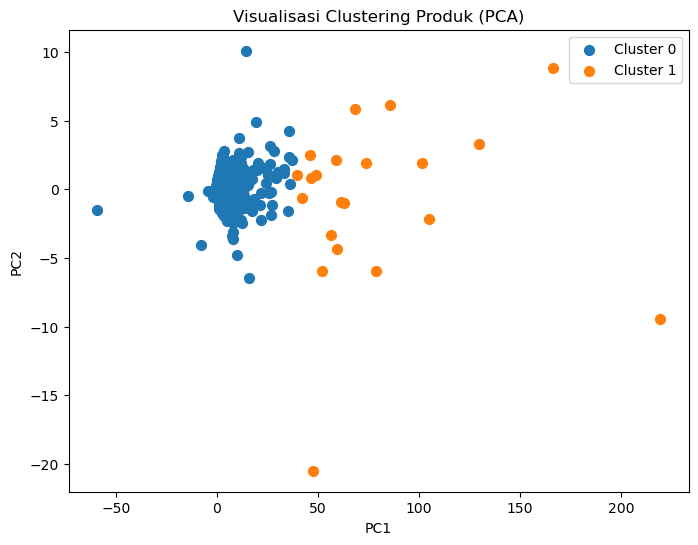

In [46]:

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pivot['PC1'] = components[:, 0]
pivot['PC2'] = components[:, 1]

plt.figure(figsize=(8,6))
for c in range(best_k):
    subset = pivot[pivot['CLUSTER']==c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f"Cluster {c}", s=50)

plt.title("Visualisasi Clustering Produk (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()
